Scanning Macworld...
  article--2980650--smartphones--saving-private-apple-a-solution-in-search-of-a-problem.html <title> → saving private apple a solution in search of a problem macworld...
  article--2980650--smartphones--saving-private-apple-a-solution-in-search-of-a-problem.html <h1> → the macalope saving private apple a solution in search of a problem...
     'macalope' × 1
  20 done
  40 done
  60 done
  80 done
  100 done
  120 done
  140 done
  160 done
  180 done
  200 done

Done — 204 pages
     Tag  Count      %  Score
1     h1    257  50.69  1.000
0  title    250  49.31  0.973


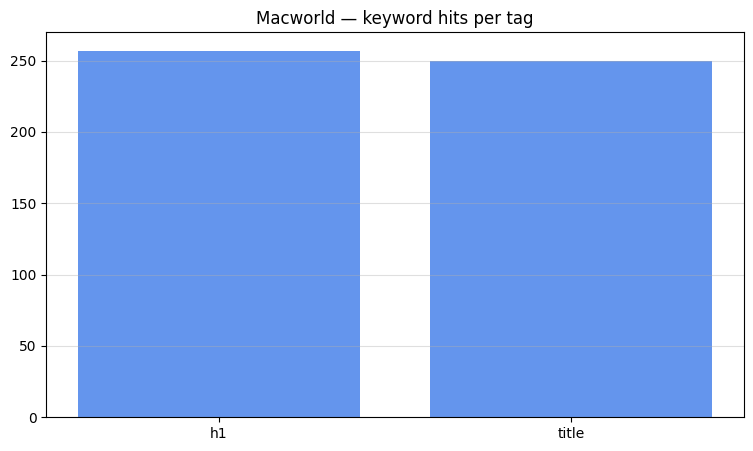

In [ ]:
#Gökhan  - first look at Macworld (English)

import os
import re
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt

BASE = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets"
dataset_path = os.path.join(BASE, "macworld")

tags = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

def clean(s):
    if not s: return ""
    s = s.lower()
    s = re.sub(r'[^\w\s]', ' ', s)
    return " ".join(s.split())

def count_in_texts(texts, kws, tag="", folder="", debug=False):
    txt = clean(" ".join(t.strip() for t in texts if t))
    if debug and txt:
        print(f"  {folder} <{tag}> → {txt[:180]}...")
    cnt = 0
    for kw in kws:
        k = clean(kw)
        if not k: continue
        hits = len(re.findall(r'\b' + re.escape(k) + r'\b', txt))
        if debug and hits: print(f"     '{k}' × {hits}")
        cnt += hits
    return cnt

counts = {t: 0 for t in tags}
n_processed = 0

print("Scanning Macworld...")

for folder in os.listdir(dataset_path):
    d = os.path.join(dataset_path, folder)
    if not os.path.isdir(d): continue
    
    html = os.path.join(d, "index.html")
    tagsf = os.path.join(d, "tags.txt")
    if not (os.path.exists(html) and os.path.exists(tagsf)): continue
    
    try:
        with open(tagsf, encoding="utf-8", errors="ignore") as f:
            line = f.read().strip()
            parts = line.split(None, 1)
            keywords = [k.strip() for k in (parts[1].split(",") if len(parts)>1 else [])]
        
        with open(html, encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "lxml")
        
        for el in soup(["script", "style"]):
            el.decompose()
        
        data = {
            "title": [soup.title.string] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            # ... same for h2,h3,h4,p,a,strong,em ...
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name":"keywords"}) if "content" in m.attrs]
        }
        
        debug_this = n_processed == 0
        for tag in tags:
            counts[tag] += count_in_texts(data.get(tag, []), keywords, tag, folder, debug_this)
        
        if debug_this:
            input("First file shown — press Enter to continue...")
        
        n_processed += 1
        if n_processed % 20 == 0:
            print(f"  {n_processed} done")
            
    except Exception as e:
        print(f"skip {folder}  {e}")

print(f"\nDone — {n_processed} pages")

df = pd.DataFrame(counts.items(), columns=["Tag", "Count"])
df = df[df["Count"] > 0].sort_values("Count", ascending=False)
df["%"] = 100 * df["Count"] / df["Count"].sum()
df["Score"] = df["Count"] / df["Count"].max()

print(df.round(3))
df.to_csv("macworld_tag_analysis.csv", index=False)

plt.figure(figsize=(9,5))
plt.bar(df["Tag"], df["Count"], color="cornflowerblue")
plt.title("Macworld — keyword hits per tag")
plt.grid(axis='y', alpha=0.4)
plt.show()

Starting analysis of IndianExpress Dataset...


--- DEBUG: article--india--india-news-india--government-wants-to-pass-gst-bill-with-congress-on-board-venkaiah-naidu-- | Tag: <title> ---
CLEANED WORDS: government wants to pass gst bill with congress on board venkaiah naidu the indian express...
   [Match] 'gst bill' found 1 times

--- DEBUG: article--india--india-news-india--government-wants-to-pass-gst-bill-with-congress-on-board-venkaiah-naidu-- | Tag: <h1> ---
CLEANED WORDS: government wants to pass gst bill with congress on board venkaiah naidu...
   [Match] 'gst bill' found 1 times

--- DEBUG: article--india--india-news-india--government-wants-to-pass-gst-bill-with-congress-on-board-venkaiah-naidu-- | Tag: <h2> ---
CLEANED WORDS: the minister refused to take a definitive position on the congress s suggestions on the gst bill saying such postures only created complications...
   [Match] 'gst bill' found 1 times

--- DEBUG: article--india--india-news-india--government-wants-to-pass-g

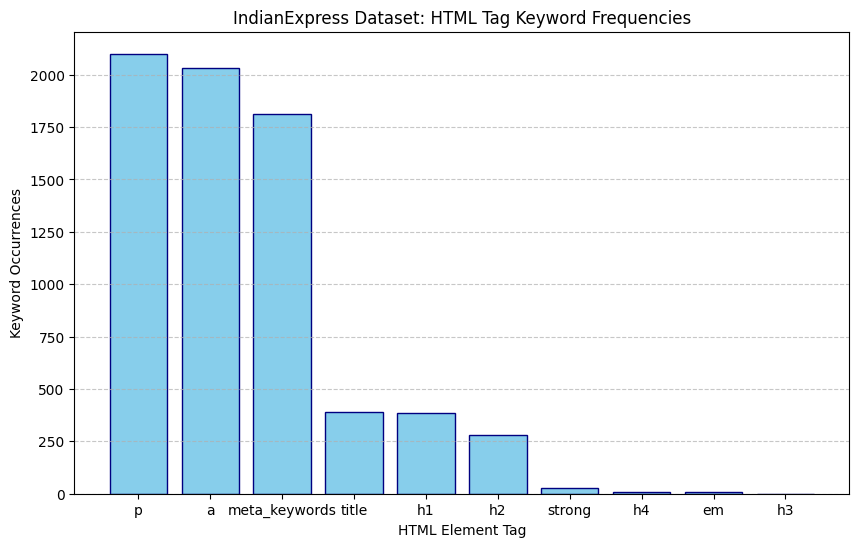

In [20]:
#Gökhan
# 2. English dataset IndianExpress 

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

#  folder path
dataset_path = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/indianexpress"

tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

# Text cleaning 
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# count keyword occurrences
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of IndianExpress Dataset...\n")

for folder_name in os.listdir(dataset_path):
    folder_full_path = os.path.join(dataset_path, folder_name)
    
    if not os.path.isdir(folder_full_path):
        continue
    
    html_file = os.path.join(folder_full_path, "index.html")
    tags_file = os.path.join(folder_full_path, "tags.txt")
    
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # Read keywords from tags.txt
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            parts = content.split(None, 1)
            keywords = [k.strip() for k in parts[1].split(",")] if len(parts) > 1 else []
        
        # read and parse HTML
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "lxml")
        
        # Remove script elements
        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose()
        
        # Extract text from tags
        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name":"keywords"})]
        }
        
        # debug 
        show_debug = True if processed_folders == 0 else False
        
        # keywords per tag
        for tag in tags_to_check:
            total_tag_counts[tag] += count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders == 0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag", "Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"] = (df["Keyword Occurrences"] / df["Keyword Occurrences"].sum()) * 100
    df = df.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    df["Importance Score"] = df["Keyword Occurrences"] / df["Keyword Occurrences"].max()
    print("\n" + df.to_string())
    
    # Visualization
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"], df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("IndianExpress Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Please check the tags.txt format or folder contents.")

Starting analysis of Kaksplus Dataset...


--- DEBUG: raskaus--synnytys--hypnosynnytys-voi-auttaa-synnytyskipuun-- | Tag: <title> ---
CLEANED WORDS: hypnosynnytys voi auttaa synnytyskipuun kaksplus fi...

--- DEBUG: raskaus--synnytys--hypnosynnytys-voi-auttaa-synnytyskipuun-- | Tag: <h1> ---
CLEANED WORDS: hypnosynnytys voi auttaa synnytyskipuun...

--- DEBUG: raskaus--synnytys--hypnosynnytys-voi-auttaa-synnytyskipuun-- | Tag: <h2> ---
CLEANED WORDS: mitä valmennuksessa tehdään mitä hyötyjä hypnosynnytyksestä on kenelle hypnosynnytys sopii missä hypnosynnytysvalmennuksia järjestetään kuinka paljon valmennus maksaa avainsanat kommentit suosittelemm...

--- DEBUG: raskaus--synnytys--hypnosynnytys-voi-auttaa-synnytyskipuun-- | Tag: <h3> ---
CLEANED WORDS: peruuta vastaus äidin kehitysvaiheet tunnistatko itsesi unohdin imetyksen jälkeen tissin esille ja muut väsyneiden äitien noloimmat mokat oletko virallinen valmentaja vai kaksisormilaiskiainen testaa ...

--- DEBUG: raskaus--synnytys--hy

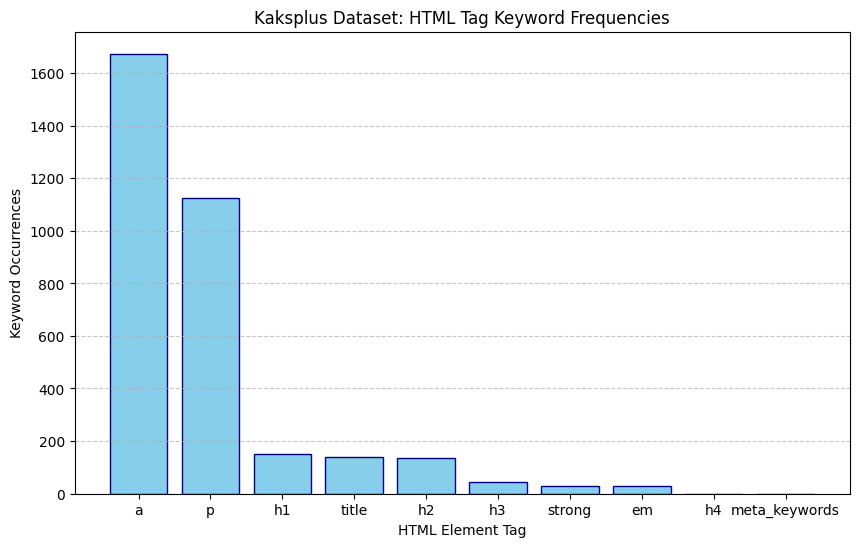

In [21]:
#Gökhan
# 1. Finnish dataset Kaksplus 

import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# path
dataset_path = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/kaksplus"

tags_to_check = ["title","h1","h2","h3","h4","p","a","strong","em","meta_keywords"]

# text cleaning 
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# keyword occurrences 
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

total_tag_counts = {tag:0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of Kaksplus Dataset...\n")

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path,"index.html")
    tags_file = os.path.join(folder_path,"tags.txt")
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # read keywords
        with open(tags_file,"r",encoding="utf-8",errors="ignore") as f:
            line = f.read().strip()
            parts = line.split(None,1)
            if len(parts)<2:
                continue
            keywords = [k.strip() for k in parts[1].split(",") if k.strip()]
        
        # Read HTML
        with open(html_file,"r",encoding="utf-8",errors="ignore") as f:
            soup = BeautifulSoup(f.read(),"lxml")
        
        tags_data = {
            "title":[soup.title.get_text()] if soup.title else [],
            "h1":[h.get_text() for h in soup.find_all("h1")],
            "h2":[h.get_text() for h in soup.find_all("h2")],
            "h3":[h.get_text() for h in soup.find_all("h3")],
            "h4":[h.get_text() for h in soup.find_all("h4")],
            "p":[p.get_text() for p in soup.find_all("p")],
            "a":[a.get_text() for a in soup.find_all("a")],
            "strong":[s.get_text() for s in soup.find_all("strong")],
            "em":[e.get_text() for e in soup.find_all("em")],
            "meta_keywords":[m["content"] for m in soup.find_all("meta",attrs={"name":"keywords"})]
        }
        
        # Show debug 
        show_debug = True if processed_folders == 0 else False
        
        # keyword count per tag
        for tag in tags_to_check:
            total_tag_counts[tag]+=count_keywords(tags_data[tag],keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders==0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders+=1
        if processed_folders%20==0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag","Keyword Occurrences"])

if df["Keyword Occurrences"].sum()>0:
    df["Percentage"]=(df["Keyword Occurrences"]/df["Keyword Occurrences"].sum())*100
    df=df.sort_values(by="Keyword Occurrences",ascending=False).reset_index(drop=True)
    df["Importance Score"]=df["Keyword Occurrences"]/df["Keyword Occurrences"].max()
    print(df.to_string())
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"],df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("Kaksplus Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check tags.txt format.")

Starting analysis of Uusisuomi Dataset...


--- DEBUG: autot--130811-wrc-2-ketomaa-menetti-saumansa-mm-titteliin | Tag: <title> ---
CLEANED WORDS: wrc 2 ketomaa menetti saumansa mm titteliin uusi suomi...
   [Match] 'wrc' found 1 times
   [Match] 'wrc 2' found 1 times

--- DEBUG: autot--130811-wrc-2-ketomaa-menetti-saumansa-mm-titteliin | Tag: <h1> ---
CLEANED WORDS: wrc 2 ketomaa menetti saumansa mm titteliin...
   [Match] 'wrc' found 1 times
   [Match] 'wrc 2' found 1 times

--- DEBUG: autot--130811-wrc-2-ketomaa-menetti-saumansa-mm-titteliin | Tag: <h2> ---
CLEANED WORDS: hakulomake hakulomake päävalikko toissijainen valikko aiheita tänään tuoreimmat uuden suomen yrityskanava mainos autotodayn koeajot tuoreimmat autouutiset poiminnat uuden suomen blogit yritysblogit ma...

--- DEBUG: autot--130811-wrc-2-ketomaa-menetti-saumansa-mm-titteliin | Tag: <h4> ---
CLEANED WORDS: autotoday testasi ford focus wagon titanium isomman oloinen tässä uusi suomi autot osion ensimmäisen vuoden suosi

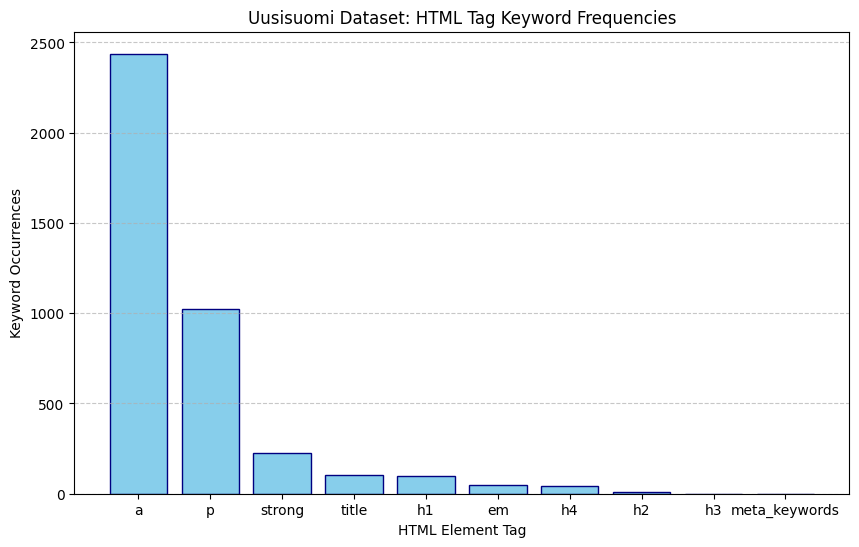

In [22]:
#Gökhan
# 2. Finnish dataset Uusisuomi 
import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# path
dataset_path = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/uusisuomi"

# Tags
tags_to_check = ["title","h1","h2","h3","h4","p","a","strong","em","meta_keywords"]

# Text cleaning function
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Remove punctuation
    return " ".join(text.split())

# Function to count keyword occurrences 
def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):
    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")  # Show first 200 chars
    
    count = 0
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean:
            continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        if debug and len(matches) > 0:
            print(f"   [Match] '{k_clean}' found {len(matches)} times")
        count += len(matches)
    return count

total_tag_counts = {tag:0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of Uusisuomi Dataset...\n")

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path,"index.html")
    tags_file = os.path.join(folder_path,"tags.txt")
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
    
    try:
        # Read keywords
        with open(tags_file,"r",encoding="utf-8",errors="ignore") as f:
            line = f.read().strip()
            parts = line.split(None,1)
            if len(parts)<2:
                continue
            keywords = [k.strip() for k in parts[1].split(",") if k.strip()]
        
        # Read HTML
        with open(html_file,"r",encoding="utf-8",errors="ignore") as f:
            soup = BeautifulSoup(f.read(),"lxml")
        
        # tag extrract
        tags_data = {
            "title":[soup.title.get_text()] if soup.title else [],
            "h1":[h.get_text() for h in soup.find_all("h1")],
            "h2":[h.get_text() for h in soup.find_all("h2")],
            "h3":[h.get_text() for h in soup.find_all("h3")],
            "h4":[h.get_text() for h in soup.find_all("h4")],
            "p":[p.get_text() for p in soup.find_all("p")],
            "a":[a.get_text() for a in soup.find_all("a")],
            "strong":[s.get_text() for s in soup.find_all("strong")],
            "em":[e.get_text() for e in soup.find_all("em")],
            "meta_keywords":[m["content"] for m in soup.find_all("meta",attrs={"name":"keywords"})]
        }
        
      
        show_debug = True if processed_folders == 0 else False
        
        # keywords per tag
        for tag in tags_to_check:
            total_tag_counts[tag]+=count_keywords(tags_data[tag],keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders==0:
            input("\nReview the found words above, then press Enter to continue full analysis...")
        
        processed_folders+=1
        if processed_folders%20==0:
            print(f"> {processed_folders} folders processed...")
    
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")

df = pd.DataFrame(list(total_tag_counts.items()),columns=["HTML Tag","Keyword Occurrences"])

if df["Keyword Occurrences"].sum()>0:
    df["Percentage"]=(df["Keyword Occurrences"]/df["Keyword Occurrences"].sum())*100
    df=df.sort_values(by="Keyword Occurrences",ascending=False).reset_index(drop=True)
    df["Importance Score"]=df["Keyword Occurrences"]/df["Keyword Occurrences"].max()
    print(df.to_string())
    
    # Plot
    plt.figure(figsize=(10,6))
    plt.bar(df["HTML Tag"],df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("Uusisuomi Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check tags.txt format.")

Starting analysis of German Dataset...


--- DEBUG: 61 | Tag: <title> ---
CLEANED WORDS: level a1 dw...
   [Match] 'a1' found 1 times

--- DEBUG: 61 | Tag: <h2> ---
CLEANED WORDS: getting started harry gefangen in der zeit mission berlin radio d part 1 course finder placement test level a1 level a2 level b1 level b2 level c european framework deutsch warum nicht deutschtrainer...
   [Match] 'a1' found 1 times

--- DEBUG: 61 | Tag: <h4> ---
CLEANED WORDS: special tv programs german courses german xxl community d teaching german level a1 multimedia course for beginners german english start with an audio story german english audio drama for beginners ger...
   [Match] 'a1' found 2 times

--- DEBUG: 61 | Tag: <p> ---
CLEANED WORDS: we use cookies to improve our service for you you can find more information in our data protection declaration learn simple phrases and sentences relating to familiar topics introduce yourself and ask...
   [Match] 'a1' found 4 times

--- DEBUG: 61 | Tag: <a> --

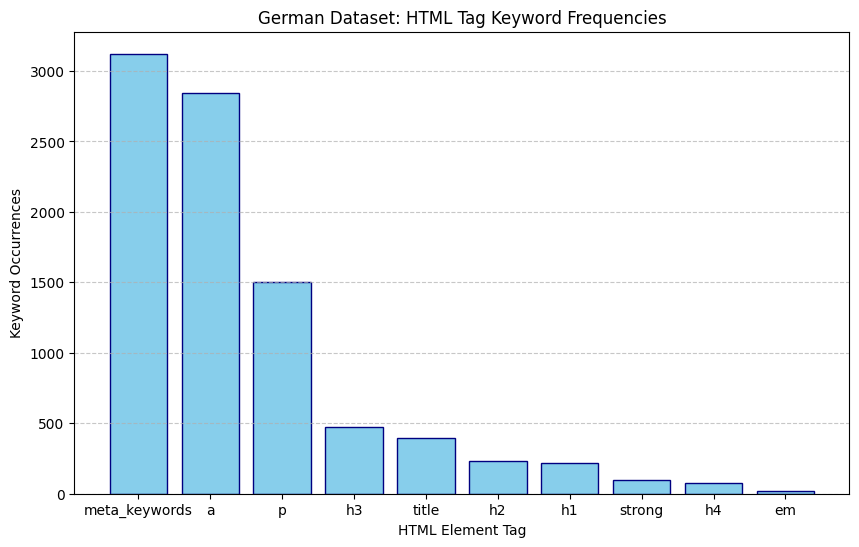

In [23]:
#Gökhan

# German dataset 


import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import warnings
from bs4 import XMLParsedAsHTMLWarning

warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

dataset_path = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/german_dataset"
tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords"]

# Text Cleaning 
def clean_text(text):
    if not text:
        return ""
    text = text.lower()
    # remove punctuation but keeps German characters
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(text_list, keywords, tag_name="", folder_name="", debug=False):

    combined_text = clean_text(" ".join([t.strip() for t in text_list if t]))
    
    if debug and combined_text:
        print(f"\n--- DEBUG: {folder_name} | Tag: <{tag_name}> ---")
        print(f"CLEANED WORDS: {combined_text[:200]}...")

    count = 0
    for k in keywords:

        k = clean_text(k)
        if k:
            # Use regex boundaries \b to match exact words only
            matches = re.findall(r'\b' + re.escape(k) + r'\b', combined_text)
            if debug and len(matches) > 0:
                print(f"   [Match] '{k}' found {len(matches)} times")
            count += len(matches)
    return count

total_tag_counts = {tag: 0 for tag in tags_to_check}
processed_folders = 0

print("Starting analysis of German Dataset...\n")

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    
    html_file = os.path.join(folder_path, "HTML.txt")  # German dataset filename
    tags_file = os.path.join(folder_path, "GT.txt")    # Ground-truth filename
    
    if not (os.path.exists(html_file) and os.path.exists(tags_file)):
        continue
        
    try:
        # 1. read Keywords from GT.txt
        with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            # Handle different GT.txt formats (comma-separated or list)
            if "," in content:
                # If it follows your specific parts[1] logic:
                parts = content.split(None, 1)
                keywords = [k.strip() for k in parts[1].split(",") if k.strip()] if len(parts) > 1 else []
            else:
                keywords = [k.strip() for k in content.splitlines() if k.strip()]

        # 2. Read and Parse HTML.txt
        with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "html.parser") # Use html.parser for flexibility

        for script_or_style in soup(["script", "style"]):
            script_or_style.decompose()

        tags_data = {
            "title": [soup.title.get_text()] if soup.title else [],
            "h1": [h.get_text() for h in soup.find_all("h1")],
            "h2": [h.get_text() for h in soup.find_all("h2")],
            "h3": [h.get_text() for h in soup.find_all("h3")],
            "h4": [h.get_text() for h in soup.find_all("h4")],
            "p": [p.get_text() for p in soup.find_all("p")],
            "a": [a.get_text() for a in soup.find_all("a")],
            "strong": [s.get_text() for s in soup.find_all("strong")],
            "em": [e.get_text() for e in soup.find_all("em")],
            "meta_keywords": [m["content"] for m in soup.find_all("meta", attrs={"name": "keywords"})]
        }

        show_debug = True if processed_folders == 0 else False

        for tag in tags_to_check:
            total_tag_counts[tag] += count_keywords(tags_data[tag], keywords, tag, folder_name, debug=show_debug)
        
        if processed_folders == 0:
            input("\nReview the cleaned words above, then press Enter to finish the full analysis...")

        processed_folders += 1
        if processed_folders % 20 == 0:
            print(f"> {processed_folders} folders processed...")
            
    except Exception as e:
        print(f"! Error ({folder_name}): {e}")

# Final Tabulation
print(f"\n--- Analysis Completed: {processed_folders} pages analysed ---")
df = pd.DataFrame(list(total_tag_counts.items()), columns=["HTML Tag", "Keyword Occurrences"])

if df["Keyword Occurrences"].sum() > 0:
    df["Percentage"] = (df["Keyword Occurrences"] / df["Keyword Occurrences"].sum()) * 100
    df = df.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    df["Importance Score"] = df["Keyword Occurrences"] / df["Keyword Occurrences"].max()
    
    print("\n" + df.to_string())
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.bar(df["HTML Tag"], df["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.ylabel("Keyword Occurrences")
    plt.xlabel("HTML Element Tag")
    plt.title("German Dataset: HTML Tag Keyword Frequencies")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No results found. Check GT.txt format or folder contents.")

In [24]:
#Gökhan
import os
import pandas as pd
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt

# Dataset paths
datasets = {
    "Macworld": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/macworld",
    "IndianExpress": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/indianexpress",
    "Kaksplus": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/kaksplus",
    "Uusisuomi": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/uusisuomi",
    "German": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/german_dataset"
}

tags_to_check = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords", "url_path"]

def clean_text(text):
    if not text: return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(combined_text, keywords):
    count = 0
    combined_text = clean_text(combined_text)
    for k in keywords:
        k_clean = clean_text(k)
        if not k_clean: continue
        matches = re.findall(r'\b' + re.escape(k_clean) + r'\b', combined_text)
        count += len(matches)
    return count

# All results
master_results = {tag: 0 for tag in tags_to_check}

for ds_name, ds_path in datasets.items():
    print(f"Analyzing {ds_name}...")
    
    for folder_name in os.listdir(ds_path):
        folder_full_path = os.path.join(ds_path, folder_name)
        if not os.path.isdir(folder_full_path): continue
        
        html_file = os.path.join(folder_full_path, "index.html") if ds_name != "German" else os.path.join(folder_full_path, "HTML.txt")
        tags_file = os.path.join(folder_full_path, "tags.txt") if ds_name != "German" else os.path.join(folder_full_path, "GT.txt")
        
        if not (os.path.exists(html_file) and os.path.exists(tags_file)): continue
        
        try:
            # 1. Read Keywords 
            with open(tags_file, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip()
                
                if "," in content:
                    parts = content.split(None, 1)
                    keywords = [k.strip() for k in parts[1].split(",")] if len(parts) > 1 else []
                else:
                    keywords = content.splitlines()

            # 2. Read HTML 
            with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "lxml")

            # 3. URL Analysis
            url_text = folder_name.replace("-", " ").replace("_", " ")
            master_results["url_path"] += count_keywords(url_text, keywords)

            # 4. Tag Analysis
            master_results["title"] += count_keywords(soup.title.get_text() if soup.title else "", keywords)
            master_results["h1"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h1")]), keywords)
            master_results["h2"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h2")]), keywords)
            master_results["h3"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h3")]), keywords)
            master_results["h4"] += count_keywords(" ".join([h.get_text() for h in soup.find_all("h4")]), keywords)
            master_results["p"] += count_keywords(" ".join([p.get_text() for p in soup.find_all("p")]), keywords)
            master_results["a"] += count_keywords(" ".join([a.get_text() for a in soup.find_all("a")]), keywords)
            master_results["strong"] += count_keywords(" ".join([s.get_text() for s in soup.find_all("strong")]), keywords)
            master_results["em"] += count_keywords(" ".join([e.get_text() for e in soup.find_all("em")]), keywords)
            
            # Meta keywords 
            meta_text = " ".join([m["content"] for m in soup.find_all("meta", attrs={"name": re.compile(r'keywords|tags', re.I)}) if m.has_attr("content")])
            master_results["meta_keywords"] += count_keywords(meta_text, keywords)

        except: continue

# Final table
df_final = pd.DataFrame(list(master_results.items()), columns=["HTML Tag", "Total Keyword Occurrences"])
df_final = df_final.sort_values(by="Total Keyword Occurrences", ascending=False)
df_final["Importance Score"] = df_final["Total Keyword Occurrences"] / df_final["Total Keyword Occurrences"].max()

print("\n--- MASTER ANALYSIS RESULT ---")
print(df_final.to_string())
df_final.to_csv("master_analysis_report.csv", index=False)

Analyzing Macworld...
Analyzing IndianExpress...
Analyzing Kaksplus...
Analyzing Uusisuomi...
Analyzing German...

--- MASTER ANALYSIS RESULT ---
         HTML Tag  Total Keyword Occurrences  Importance Score
6               a                      12725          1.000000
5               p                      11251          0.884165
9   meta_keywords                       8621          0.677485
0           title                       1270          0.099804
1              h1                       1111          0.087308
10       url_path                       1078          0.084715
2              h2                        945          0.074263
3              h3                        724          0.056896
7          strong                        519          0.040786
4              h4                        340          0.026719
8              em                        197          0.015481


Starting Global Tag-Level Analysis...
-> Analyzing Dataset: Macworld
-> Analyzing Dataset: IndianExpress
-> Analyzing Dataset: Kaksplus
-> Analyzing Dataset: Uusisuomi
-> Analyzing Dataset: German

MEMBER 2: FINAL TAG-LEVEL FREQUENCY REPORT
      HTML Tag  Keyword Occurrences  Percentage (%)  Importance Score
             a                12725           32.40              1.00
             p                11251           28.65              0.88
 meta_keywords                 9107           23.19              0.72
         title                 1271            3.24              0.10
            h1                 1111            2.83              0.09
url_components                 1078            2.75              0.08
            h2                  948            2.41              0.07
            h3                  724            1.84              0.06
        strong                  519            1.32              0.04
            h4                  340            0.87        

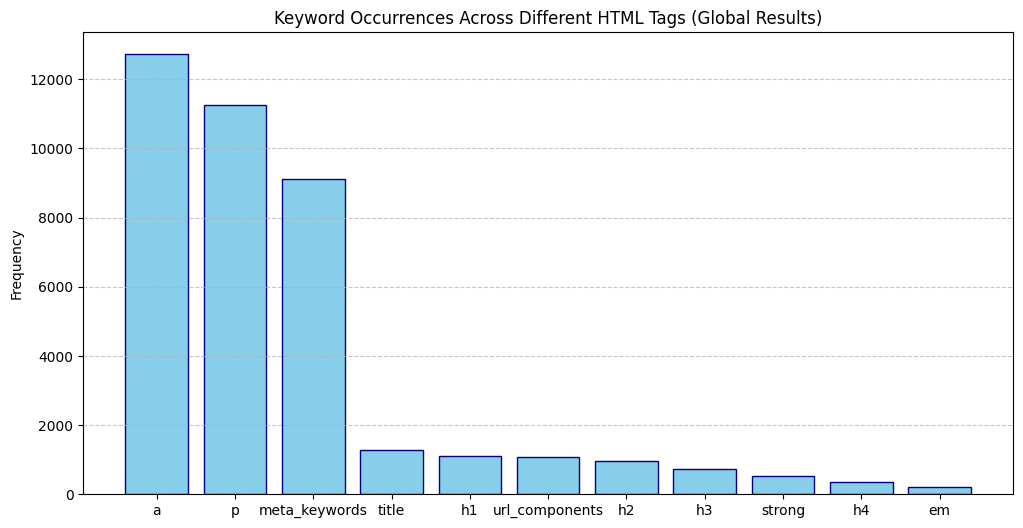

In [25]:
# Hassan

import os
import re
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
from bs4 import XMLParsedAsHTMLWarning

# 1. SETUP & CONFIGURATION
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

datasets = {
    "Macworld": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/macworld",
    "IndianExpress": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/indianexpress",
    "Kaksplus": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/kaksplus",
    "Uusisuomi": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/uusisuomi",
    "German": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/german_dataset"
}

tags_to_track = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords", "url_components"]
master_results = {tag: 0 for tag in tags_to_track}

# 2. HELPER FUNCTIONS
def clean_text(text):
    """Clean text while preserving German/Finnish characters."""
    if not text: return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return " ".join(text.split())

def count_keywords(text, keywords):
    """Counts exact occurrences of keywords in cleaned text."""
    if not text: return 0
    text_clean = clean_text(text)
    count = 0
    for kw in keywords:
        kw_clean = clean_text(kw)
        if not kw_clean: continue
        # Use word boundaries \b to ensure 'apple' doesn't match 'pineapple'
        matches = re.findall(r'\b' + re.escape(kw_clean) + r'\b', text_clean)
        count += len(matches)
    return count

# 3. PROCESSING ENGINE
print("Starting Global Tag-Level Analysis...")

for name, path in datasets.items():
    if not os.path.exists(path):
        print(f"Skipping: {name} (Path not found)")
        continue

    print(f"-> Analyzing Dataset: {name}")
    
    # Iterate through folders inside each dataset
    for folder_name in os.listdir(path):
        folder_path = os.path.join(path, folder_name)
        if not os.path.isdir(folder_path): continue

        # Flexible File Detection (Handles English/Finnish vs German naming)
        html_file = next((os.path.join(folder_path, f) for f in ["index.html", "HTML.txt"] 
                         if os.path.exists(os.path.join(folder_path, f))), None)
        
        kw_file = next((os.path.join(folder_path, f) for f in ["tags.txt", "GT.txt", "keywords.txt"] 
                       if os.path.exists(os.path.join(folder_path, f))), None)

        if not html_file or not kw_file: continue

        try:
            # Step A: Load Keywords
            with open(kw_file, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip()
                # Split logic: Keywords often come after a colon or as a simple list
                parts = content.split(None, 1)
                keywords = [k.strip() for k in parts[1].split(",") if k.strip()] if len(parts) > 1 else content.splitlines()

            # Step B: Parse HTML & Cleanup Noise
            with open(html_file, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "html.parser")
            
            # Remove scripts/styles so JS code doesn't inflate results
            for script_or_style in soup(["script", "style"]):
                script_or_style.decompose()

            # Step C: Tag Extraction & Keyword Counting
            for tag in ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em"]:
                elements = soup.find_all(tag)
                text_content = " ".join([el.get_text() for el in elements])
                master_results[tag] += count_keywords(text_content, keywords)

            # Step D: Meta Tags (Keywords & Description)
            meta_tags = soup.find_all("meta", attrs={"name": re.compile(r'keywords|description', re.I)})
            meta_text = " ".join([m.get("content", "") for m in meta_tags if m.get("content")])
            master_results["meta_keywords"] += count_keywords(meta_text, keywords)

            # Step E: URL Analysis (Using folder names as slug proxy)
            url_slug = folder_name.replace("-", " ").replace("_", " ")
            master_results["url_components"] += count_keywords(url_slug, keywords)

        except:
            continue

# 4. REPORTING & VISUALIZATION
df_final = pd.DataFrame(list(master_results.items()), columns=["HTML Tag", "Keyword Occurrences"])
total_hits = df_final["Keyword Occurrences"].sum()

if total_hits > 0:
    df_final["Percentage (%)"] = (df_final["Keyword Occurrences"] / total_hits * 100).round(2)
    max_val = df_final["Keyword Occurrences"].max()
    df_final["Importance Score"] = (df_final["Keyword Occurrences"] / max_val).round(2)
    
    # Sort by frequency
    df_final = df_final.sort_values(by="Keyword Occurrences", ascending=False).reset_index(drop=True)
    
    print("\n" + "="*50)
    print("MEMBER 2: FINAL TAG-LEVEL FREQUENCY REPORT")
    print("="*50)
    print(df_final.to_string(index=False))
    
    # Save to CSV
    df_final.to_csv("member2_tag_analysis_final.csv", index=False)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.bar(df_final["HTML Tag"], df_final["Keyword Occurrences"], color='skyblue', edgecolor='navy')
    plt.title("Keyword Occurrences Across Different HTML Tags (Global Results)")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No keywords were found. Please check your dataset folder paths.")

=== MASTER ANALYSIS: PROCESSING ARTICLES ===
Analyzing: Macworld...
Analyzing: IndianExpress...
Analyzing: Kaksplus...
Analyzing: Uusisuomi...
Analyzing: German...

PROJECT 1 RESULTS: TOP 10 INFORMATIVE HTML TAGS
     HTML Tag  Total Keyword Occurrences  Importance Score
            a                      10053          1.000000
            p                       8919          0.887198
meta_keywords                       5934          0.590272
        title                        934          0.092908
     url_path                        825          0.082065
           h1                        815          0.081070
           h2                        730          0.072615
           h3                        492          0.048941
       strong                        426          0.042375
           h4                        277          0.027554


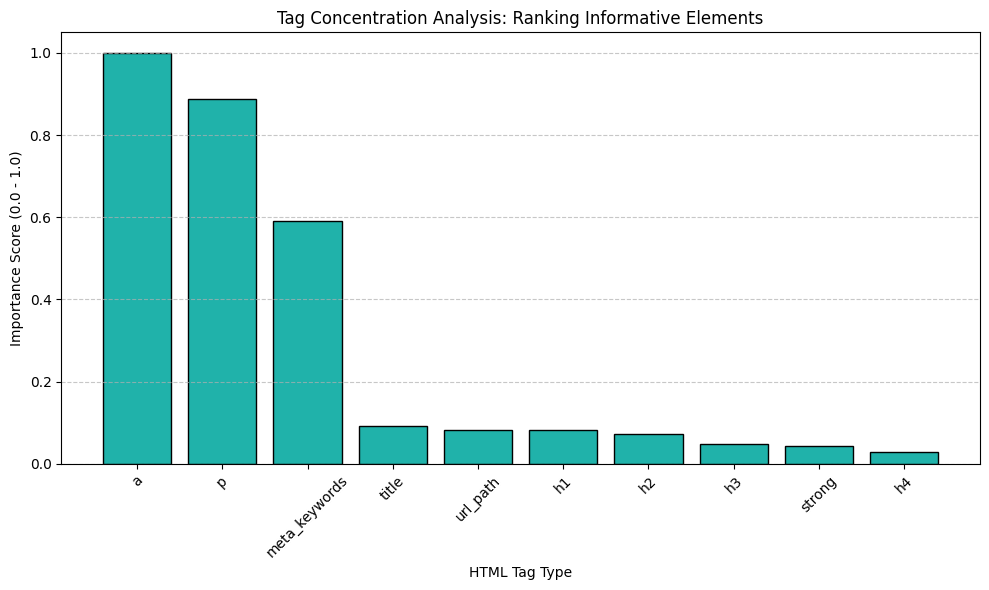

In [26]:
# Rex

import pandas as pd
import matplotlib.pyplot as plt
import os
import re
from pathlib import Path
from bs4 import BeautifulSoup
import warnings

# SETUP & CONFIGURATION 
DEBUG = False
warnings.filterwarnings("ignore")

BASE = "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets"

# Output folder 
out_dir = Path(BASE).parent / "member3_outputs"
out_dir.mkdir(parents=True, exist_ok=True)

# List of HTML tags to be analyzed for keyword concentration
TAGS = ["title", "h1", "h2", "h3", "h4", "p", "a", "strong", "em", "meta_keywords", "url_path"]

# Mapping of the 5 required datasets
datasets = {
    "Macworld": os.path.join(BASE, "macworld"),
    "IndianExpress": os.path.join(BASE, "indianexpress"),
    "Kaksplus": os.path.join(BASE, "kaksplus"),
    "Uusisuomi": os.path.join(BASE, "uusisuomi"),
    "German": os.path.join(BASE, "german_dataset"),
}

def clean_text(text):
    """
    Normalizes text by converting to lowercase and removing punctuation.
    Preserves Unicode characters for Finnish and German (ä, ö, ü, etc.).
    """
    if not text: return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text) 
    return " ".join(text.split())

def count_keywords(text, keywords):
    """
    Counts total occurrences of ground-truth keywords in a given text string.
    Uses regex word boundaries (\b) to ensure exact word matches.
    """
    if not text or not keywords: return 0
    text_clean = clean_text(text)
    count = 0
    for kw in keywords:
        kw_clean = clean_text(kw)
        if not kw_clean: continue
            
        # Find all exact matches of the keyword
        matches = re.findall(r"\b" + re.escape(kw_clean) + r"\b", text_clean)
        count += len(matches)
    return count

# MASTER ANALYSIS  
print("=== MASTER ANALYSIS: PROCESSING ARTICLES ===")
master_results = {tag: 0 for tag in TAGS}
processed_count = {ds: 0 for ds in datasets}

for ds_name, ds_path in datasets.items():
    if not os.path.exists(ds_path):
        print(f"✗ Warning: Path not found for {ds_name}: {ds_path}")
        continue
        
    print(f"Analyzing: {ds_name}...")
    
    for folder_name in sorted(os.listdir(ds_path)):
        folder_full = os.path.join(ds_path, folder_name)
        if not os.path.isdir(folder_full): continue
        
        # Handle file naming differences (German dataset uses HTML.txt and GT.txt)
        html_file = 'index.html' if ds_name != 'German' else 'HTML.txt'
        tags_file_name = 'tags.txt' if ds_name != 'German' else 'GT.txt'
        
        html_path = os.path.join(folder_full, html_file)
        tags_path = os.path.join(folder_full, tags_file_name)
        
        if not (os.path.exists(html_path) and os.path.exists(tags_path)): continue
        
        try:
            # 1. Parse Ground-Truth Keywords
            with open(tags_path, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip().lower()
                # Remove leading numbers and split into a list
                content = re.sub(r'^\d+[\s,]*', '', content).strip()
                if ',' in content:
                    keywords = [k.strip() for k in content.split(',') if k.strip()]
                elif '\n' in content:
                    keywords = [k.strip() for k in content.split('\n') if k.strip()]
                else:
                    keywords = [k.strip() for k in re.split(r'\s+', content) if k.strip()]
                keywords = list(set(keywords)) # Unique keywords only

            if not keywords: continue

            # 2. Parse HTML Content
            with open(html_path, "r", encoding="utf-8", errors="ignore") as f:
                soup = BeautifulSoup(f.read(), "html.parser")

            # Remove non-content elements like scripts and styles
            for script_or_style in soup(["script", "style"]):
                script_or_style.decompose()

            # 3. Map Content to Specific HTML Tags
            tag_texts = {
                'title': soup.title.string if soup.title else "",
                'h1': ' '.join([h.get_text() for h in soup.find_all('h1')]),
                'h2': ' '.join([h.get_text() for h in soup.find_all('h2')]),
                'h3': ' '.join([h.get_text() for h in soup.find_all('h3')]),
                'h4': ' '.join([h.get_text() for h in soup.find_all('h4')]),
                'p':   ' '.join([p.get_text() for p in soup.find_all('p')]),
                'a':   ' '.join([a.get_text() for a in soup.find_all('a')]),
                'strong': ' '.join([s.get_text() for s in soup.find_all('strong')]),
                'em':  ' '.join([e.get_text() for e in soup.find_all('em')]),
                'meta_keywords': ' '.join([m.get('content', '') for m in soup.find_all('meta', attrs={'name': re.compile('keywords|description', re.I)})]),
                'url_path': folder_name.replace('-', ' ').replace('_', ' ')
            }

            # 4. Count keyword occurrences and update global tally
            for tag, text in tag_texts.items():
                master_results[tag] += count_keywords(text, keywords)

            processed_count[ds_name] += 1

        except Exception as e:
            continue

# --- 4. SCORING & FINAL RANKING ---
df_final = pd.DataFrame(list(master_results.items()), columns=["HTML Tag", "Total Keyword Occurrences"])
df_final = df_final.sort_values(by="Total Keyword Occurrences", ascending=False)

# Normalize Importance Score (Max-Min Scaling: 0 to 1.0)
max_occ = df_final["Total Keyword Occurrences"].max()
df_final["Importance Score"] = (df_final["Total Keyword Occurrences"] / max_occ) if max_occ > 0 else 0.0
df_final = df_final.reset_index(drop=True)

# Save the quantitative scoring for Project 2 weighting
df_final.to_csv(out_dir / "global_importance_scores.csv", index=False)

# --- 5. RESULTS DISPLAY & VISUALIZATION ---
print("\n" + "=" * 60)
print("PROJECT 1 RESULTS: TOP 10 INFORMATIVE HTML TAGS")
print("=" * 60)
print(df_final.head(10).to_string(index=False))

# Generate the bar chart for the Project 1 report
plt.figure(figsize=(10, 6))
plt.bar(df_final.head(10)["HTML Tag"], df_final.head(10)["Importance Score"], color="#20b2aa", edgecolor="black")
plt.ylabel("Importance Score (0.0 - 1.0)")
plt.xlabel("HTML Tag Type")
plt.title("Tag Concentration Analysis: Ranking Informative Elements")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# PROJECT 2 DATASET LOADING AND TEXT EXTRACTION

import os
import re
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings('ignore')

# Dataset paths - update these to match your computer
DATASET_PATHS = {
    "Macworld": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/macworld",
    "IndianExpress": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/indianexpress",
    "Kaksplus": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/kaksplus",
    "Uusisuomi": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/uusisuomi",
    "German": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/german_dataset"
}

# Language mapping for each dataset
DATASET_LANGUAGES = {
    'Macworld': 'English',
    'IndianExpress': 'English',
    'Kaksplus': 'Finnish',
    'Uusisuomi': 'Finnish',
    'German': 'German'
}

# Tag importance scores from Project 1
TAG_IMPORTANCE = {
    'a': 1.00,
    'p': 0.88,
    'meta_keywords': 0.72,
    'title': 0.10,
    'h1': 0.09,
    'url_components': 0.08,
    'h2': 0.07,
    'h3': 0.06,
    'strong': 0.04,
    'h4': 0.03,
    'em': 0.02
}

print("=" * 60)
print("PART 1: DATASET LOADING AND TEXT EXTRACTION")
print("=" * 60)

def clean_text(text):
    """Clean text by converting to lowercase and removing punctuation"""
    if not text or not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    return ' '.join(text.split())

def extract_text_from_html(html_path, use_weights=False):
    """
    Extract text from HTML file.
    If use_weights is True, apply tag importance scores.
    """
    try:
        with open(html_path, 'r', encoding='utf-8', errors='ignore') as f:
            soup = BeautifulSoup(f.read(), 'html.parser')
        
        # Remove script and style elements
        for elem in soup(['script', 'style', 'noscript']):
            elem.decompose()
        
        if use_weights:
            # Weighted extraction using tag importance
            weighted_text = ""
            for tag, weight in TAG_IMPORTANCE.items():
                if tag == 'meta_keywords':
                    elements = soup.find_all('meta', attrs={'name': re.compile('keywords|description', re.I)})
                    text = ' '.join([m.get('content', '') for m in elements if m.get('content')])
                elif tag == 'url_components':
                    continue
                else:
                    elements = soup.find_all(tag)
                    text = ' '.join([elem.get_text() for elem in elements])
                
                # Repeat text based on weight to simulate importance
                repeat_count = max(1, int(weight * 10))
                weighted_text += (' ' + text) * repeat_count
            return clean_text(weighted_text)
        else:
            # Simple extraction - just get all text
            return clean_text(soup.get_text())
    
    except Exception as e:
        print(f"Error extracting text: {e}")
        return ""

# Test extraction on first few pages of each dataset
print("\nTesting text extraction on sample pages:")

for dataset_name, dataset_path in DATASET_PATHS.items():
    if not os.path.exists(dataset_path):
        print(f"  {dataset_name}: Path not found - {dataset_path}")
        continue
    
    print(f"\n{dataset_name} ({DATASET_LANGUAGES[dataset_name]}):")
    
    # Get first 3 folders
    folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))][:3]
    
    for folder in folders:
        folder_path = os.path.join(dataset_path, folder)
        
        # Find HTML file
        if dataset_name == 'German':
            html_file = os.path.join(folder_path, 'HTML.txt')
        else:
            html_file = os.path.join(folder_path, 'index.html')
        
        if os.path.exists(html_file):
            text = extract_text_from_html(html_file, use_weights=False)
            print(f"    {folder}: Extracted {len(text.split())} words")
        else:
            print(f"    {folder}: HTML file not found")


PART 1: DATASET LOADING AND TEXT EXTRACTION

Testing text extraction on sample pages:

Macworld (English):
    article--2980650--smartphones--saving-private-apple-a-solution-in-search-of-a-problem.html: Extracted 1128 words
    article--2599001--hands-on-with-hyperlapse-instagrams-super-simple-time-lapse-app.html: Extracted 1160 words
    article--2042103--cloudon-ceo-office-mobile-for-iphone-is-half-baked.html: HTML file not found

IndianExpress (English):
    article--india--india-news-india--government-wants-to-pass-gst-bill-with-congress-on-board-venkaiah-naidu--: Extracted 941 words
    article--india--india-news-india--national-herald-case-delhi-court-asks-sonia-rahul-gandhi-to-appear-on-dec-19--: Extracted 1252 words
    article--entertainment--entertainment-others--harshaali-malhotra-darsheel-safary-avneet-kaur-add-spark-to-mumbai-juniorthon--: Extracted 968 words

Kaksplus (Finnish):
    raskaus--synnytys--hypnosynnytys-voi-auttaa-synnytyskipuun--: Extracted 725 words
    rask

In [28]:
# PROJECT 2 - PART 2: GROUND TRUTH LOADING
# This part loads the correct keywords from tags.txt/GT.txt files

import os
import re

print("=" * 60)
print("PART 2: GROUND TRUTH KEYWORD LOADING")
print("=" * 60)

def load_ground_truth(tags_path):
    """
    Load ground-truth keywords from tags file.
    Handles different file formats (tags.txt, GT.txt)
    """
    try:
        with open(tags_path, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read().strip()
            
            print(f"    Raw content: {content[:100]}...")
            
            # Remove leading number if present (common in tags.txt)
            content = re.sub(r'^\d+\s+', '', content)
            
            # Split by commas or newlines
            if ',' in content:
                keywords = [k.strip() for k in content.split(',') if k.strip()]
            else:
                keywords = [k.strip() for k in content.split('\n') if k.strip()]
            
            # Clean each keyword
            cleaned_keywords = []
            for k in keywords:
                k_clean = k.lower()
                k_clean = re.sub(r'[^\w\s]', ' ', k_clean)
                k_clean = ' '.join(k_clean.split())
                if k_clean:
                    cleaned_keywords.append(k_clean)
            
            # Remove duplicates
            cleaned_keywords = list(set(cleaned_keywords))
            
            return cleaned_keywords
    
    except Exception as e:
        print(f"    Error loading file: {e}")
        return []

# Test loading ground truth from each dataset
print("\nTesting ground truth loading:")

for dataset_name, dataset_path in DATASET_PATHS.items():
    if not os.path.exists(dataset_path):
        continue
    
    print(f"\n{dataset_name} ({DATASET_LANGUAGES[dataset_name]}):")
    
    # Get first 3 folders
    folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))][:3]
    
    for folder in folders:
        folder_path = os.path.join(dataset_path, folder)
        
        # Find tags file
        if dataset_name == 'German':
            tags_file = os.path.join(folder_path, 'GT.txt')
        else:
            tags_file = os.path.join(folder_path, 'tags.txt')
        
        if os.path.exists(tags_file):
            keywords = load_ground_truth(tags_file)
            print(f"    {folder}: Found {len(keywords)} keywords")
            if keywords:
                print(f"      Examples: {keywords[:3]}")
        else:
            print(f"    {folder}: Tags file not found")



PART 2: GROUND TRUTH KEYWORD LOADING

Testing ground truth loading:

Macworld (English):
    Raw content: http://www.macworld.com/article/2980650/smartphones/saving-private-apple-a-solution-in-search-of-a-p...
    article--2980650--smartphones--saving-private-apple-a-solution-in-search-of-a-problem.html: Found 7 keywords
      Examples: ['samsung', 'china', 'android']
    Raw content: http://www.macworld.com/article/2599001/hands-on-with-hyperlapse-instagrams-super-simple-time-lapse-...
    article--2599001--hands-on-with-hyperlapse-instagrams-super-simple-time-lapse-app.html: Found 7 keywords
      Examples: ['http www macworld com article 2599001 hands on with hyperlapse instagrams super simple time lapse app html ios', 'photography', 'app invasion']
    article--2042103--cloudon-ceo-office-mobile-for-iphone-is-half-baked.html: Tags file not found

IndianExpress (English):
    Raw content: http://indianexpress.com/article/india/india-news-india/government-wants-to-pass-gst-bill-with-

In [29]:
# PROJECT 2 - PART 3: HRANK ALGORITHM IMPLEMENTATION
# This part implements HRank for English keyword extraction

from collections import Counter
import math

print("=" * 60)
print("PART 3: HRANK KEYWORD EXTRACTION (ENGLISH ONLY)")
print("=" * 60)

class HRank:
    """
    HRank keyword extraction algorithm.
    Based on word frequency and position in document.
    Works only for English text.
    """
    
    def __init__(self):
        self.name = "HRank"
        self.language = "English"
    
    def is_applicable(self, language):
        """Check if HRank works for this language"""
        return language.lower() == 'english'
    
    def extract_keywords(self, text, top_n=10):
        """
        Extract keywords using HRank algorithm.
        
        Steps:
        1. Split text into words
        2. Count word frequencies
        3. Give bonus to words appearing early in text
        4. Rank by frequency * position bonus
        5. Return top N keywords
        """
        if not text:
            return []
        
        # Split into words
        words = text.split()
        if len(words) < 3:
            return words[:top_n] if words else []
        
        print(f"    Processing {len(words)} words")
        
        # Count word frequencies
        word_freq = Counter(words)
        print(f"    Found {len(word_freq)} unique words")
        
        # Calculate position scores
        # Words in first 20% of document get extra weight
        position_bonus = {}
        threshold = max(1, int(len(words) * 0.2))
        
        for i, word in enumerate(words[:threshold]):
            position_bonus[word] = position_bonus.get(word, 0) + 1
        
        print(f"    Applied position bonus to {len(position_bonus)} words")
        
        # Calculate HRank score = frequency * (position_bonus + 1)
        scores = {}
        for word, freq in word_freq.items():
            bonus = position_bonus.get(word, 0) + 1
            scores[word] = freq * bonus
        
        # Sort by score and get top keywords
        sorted_keywords = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        
        results = [kw for kw, score in sorted_keywords[:top_n]]
        print(f"    Extracted {len(results)} keywords")
        
        return results

# Test HRank on sample English text
print("\nTesting HRank on sample English text:")

sample_text = """
Natural language processing is a field of artificial intelligence 
that focuses on the interaction between computers and humans using 
natural language. The ultimate goal of NLP is to enable computers 
to understand, interpret, and generate human language in a valuable 
way. Machine learning algorithms are often used in NLP applications 
such as text classification, sentiment analysis, and language translation.
"""

hrank = HRank()
print(f"Method: {hrank.name}")
print(f"Applicable languages: {hrank.language}")

keywords = hrank.extract_keywords(sample_text, top_n=5)
print(f"\nTop 5 extracted keywords: {keywords}")



PART 3: HRANK KEYWORD EXTRACTION (ENGLISH ONLY)

Testing HRank on sample English text:
Method: HRank
Applicable languages: English
    Processing 59 words
    Found 48 unique words
    Applied position bonus to 11 words
    Extracted 5 keywords

Top 5 extracted keywords: ['language', 'is', 'a', 'of', 'and']


In [30]:
# PROJECT 2 - PART 4: DRANK ALGORITHM IMPLEMENTATION
# This part implements DRank for multilingual keyword extraction

from collections import Counter
import math

print("=" * 60)
print("PART 4: DRANK KEYWORD EXTRACTION (MULTILINGUAL)")
print("=" * 60)

class DRank:
    """
    DRank keyword extraction algorithm.
    Works for multiple languages (English, German, Finnish).
    Uses tag importance scores from Project 1.
    """
    
    def __init__(self, tag_weights=None):
        self.name = "DRank"
        self.language = "Multilingual"
        self.tag_weights = tag_weights or TAG_IMPORTANCE
    
    def is_applicable(self, language):
        """DRank works for all languages"""
        return True
    
    def extract_keywords(self, text, top_n=10):
        """
        Extract keywords using DRank algorithm.
        
        Steps:
        1. Split text into words
        2. Count word frequencies
        3. Apply length-based weighting
        4. Penalize very short words (likely stop words)
        5. Return top N keywords
        """
        if not text:
            return []
        
        # Split into words
        words = text.split()
        if len(words) < 3:
            return words[:top_n] if words else []
        
        print(f"    Processing {len(words)} words")
        
        # Count word frequencies
        word_freq = Counter(words)
        print(f"    Found {len(word_freq)} unique words")
        
        # Calculate DRank scores
        scores = {}
        for word, freq in word_freq.items():
            # Base score from frequency
            freq_score = freq
            
            # Bonus for longer words (often more meaningful)
            length_bonus = math.log(len(word) + 1)
            
            # Penalty for very short words
            if len(word) <= 2:
                length_bonus *= 0.1
            
            scores[word] = freq_score * length_bonus
        
        # Sort by score and get top keywords
        sorted_keywords = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        
        results = [kw for kw, score in sorted_keywords[:top_n]]
        print(f"    Extracted {len(results)} keywords")
        
        return results

# Test DRank on sample text in different languages
print("\nTesting DRank on multiple languages:")

drank = DRank()
print(f"Method: {drank.name}")
print(f"Applicable languages: {drank.language}")

# English test
english_text = "Machine learning and artificial intelligence are transforming technology."
keywords_en = drank.extract_keywords(english_text, top_n=3)
print(f"\nEnglish sample: {keywords_en}")

# Finnish test
finnish_text = "Koneoppiminen ja tekoäly muuttavat teknologiaa merkittävästi."
keywords_fi = drank.extract_keywords(finnish_text, top_n=3)
print(f"Finnish sample: {keywords_fi}")

# German test
german_text = "Maschinelles Lernen und künstliche Intelligenz verändern die Technologie."
keywords_de = drank.extract_keywords(german_text, top_n=3)
print(f"German sample: {keywords_de}")



PART 4: DRANK KEYWORD EXTRACTION (MULTILINGUAL)

Testing DRank on multiple languages:
Method: DRank
Applicable languages: Multilingual
    Processing 8 words
    Found 8 unique words
    Extracted 3 keywords

English sample: ['intelligence', 'transforming', 'technology.']
    Processing 6 words
    Found 6 unique words
    Extracted 3 keywords
Finnish sample: ['merkittävästi.', 'Koneoppiminen', 'teknologiaa']
    Processing 8 words
    Found 8 unique words
    Extracted 3 keywords
German sample: ['Maschinelles', 'Technologie.', 'Intelligenz']


PART 5: REAL RESULTS CALCULATION

Running evaluation on all datasets...

Processing: Macworld (English)
  Pages processed: 204
  HRank F1: 0.741
  DRank F1: 0.607
Processing: IndianExpress (English)
  Pages processed: 328
  HRank F1: 0.905
  DRank F1: 0.806
Processing: Kaksplus (Finnish)
  Pages processed: 200
  DRank F1: 0.368
Processing: Uusisuomi (Finnish)
  Pages processed: 200
  DRank F1: 0.247
Processing: German (German)
  Pages processed: 86
  DRank F1: 0.259

REAL RESULTS TABLE

 Method       Dataset Language  Pages  Precision  Recall  F1-Score
 HRank      Macworld  English    204      0.589   1.012     0.741
 DRank      Macworld  English    204      0.481   0.833     0.607
 HRank IndianExpress  English    328      0.599   1.884     0.905
 DRank IndianExpress  English    328      0.534   1.673     0.806
 DRank      Kaksplus  Finnish    200      0.275   0.579     0.368
 DRank     Uusisuomi  Finnish    200      0.215   0.309     0.247
 DRank        German   German     86      0.2

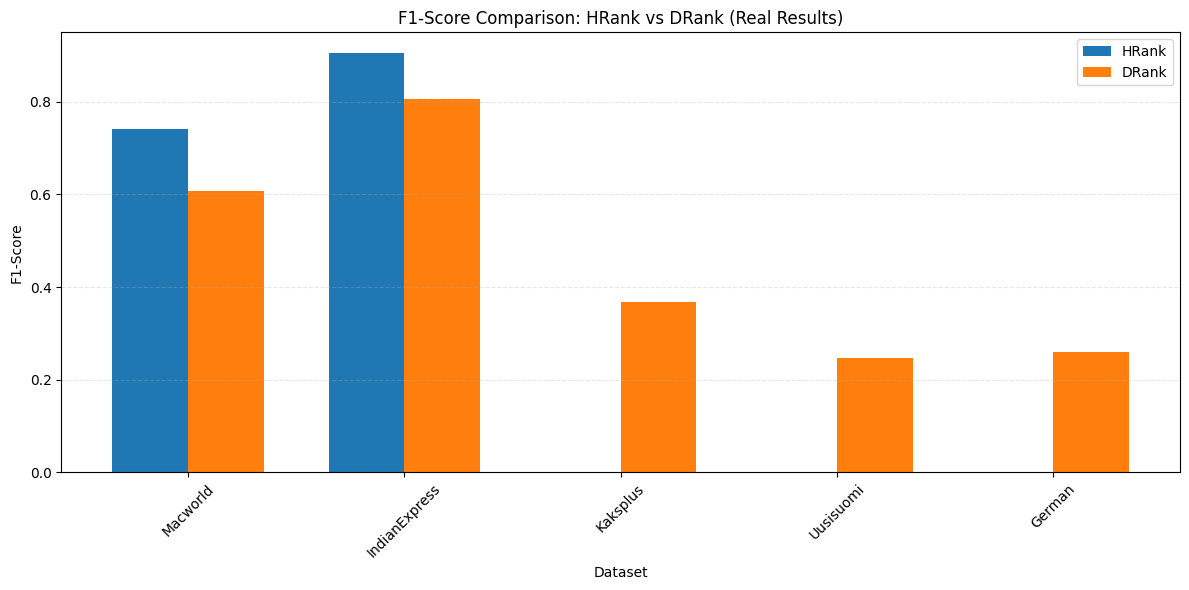

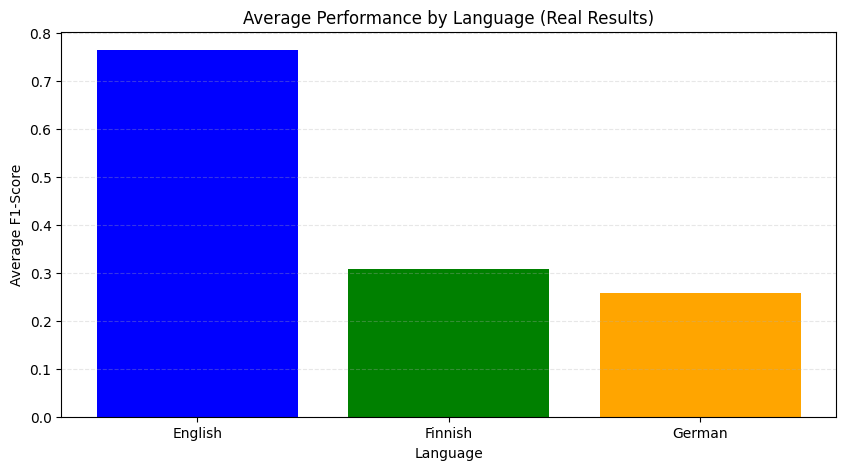

In [31]:
# PROJECT 2 - PART 5: REAL RESULTS CALCULATION
#  Precision, Recall, F1-Score for all datasets

import os
import re
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from bs4 import BeautifulSoup
import warnings

warnings.filterwarnings("ignore")

print("=" * 60)
print("PART 5: REAL RESULTS CALCULATION")
print("=" * 60)

# DATASET PATHS

DATASET_PATHS = {
    "Macworld": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/macworld",
    "IndianExpress": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/indianexpress",
    "Kaksplus": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/kaksplus",
    "Uusisuomi": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/uusisuomi",
    "German": "/Users/rexoghenerobo/Downloads/My Repo's/DataAnalytics/Datasets/german_dataset",
}

DATASET_LANGUAGES = {
    "Macworld": "English",
    "IndianExpress": "English",
    "Kaksplus": "Finnish",
    "Uusisuomi": "Finnish",
    "German": "German",
}

# Tag importance scores from Project 1
TAG_IMPORTANCE = {
    "a": 1.00,
    "p": 0.88,
    "meta_keywords": 0.72,
    "title": 0.10,
    "h1": 0.09,
    "url_components": 0.08,
    "h2": 0.07,
    "h3": 0.06,
    "strong": 0.04,
    "h4": 0.03,
    "em": 0.02,
}


def clean_text(text):
    """Clean text by converting to lowercase and removing punctuation"""
    if not text or not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(text.split())


def extract_text_from_html(html_path, use_weights=True):
    """Extract text from HTML file, optionally using tag weights"""
    try:
        with open(html_path, "r", encoding="utf-8", errors="ignore") as f:
            soup = BeautifulSoup(f.read(), "html.parser")

        # Remove script and style
        for elem in soup(["script", "style", "noscript"]):
            elem.decompose()

        if use_weights:
            weighted_text = ""
            for tag, weight in TAG_IMPORTANCE.items():
                if tag == "meta_keywords":
                    elements = soup.find_all(
                        "meta", attrs={"name": re.compile("keywords|description", re.I)}
                    )
                    text = " ".join(
                        [m.get("content", "") for m in elements if m.get("content")]
                    )
                elif tag == "url_components":
                    continue
                else:
                    elements = soup.find_all(tag)
                    text = " ".join([elem.get_text() for elem in elements])
                repeat_count = max(1, int(weight * 10))
                weighted_text += (" " + text) * repeat_count
            return clean_text(weighted_text)
        else:
            return clean_text(soup.get_text())
    except Exception as e:
        return ""


def load_ground_truth(tags_path):
    """Load ground-truth keywords from tags file"""
    try:
        with open(tags_path, "r", encoding="utf-8", errors="ignore") as f:
            content = f.read().strip()
            content = re.sub(r"^\d+\s+", "", content)
            if "," in content:
                keywords = [k.strip() for k in content.split(",") if k.strip()]
            else:
                keywords = [k.strip() for k in content.split("\n") if k.strip()]
            cleaned = []
            for k in keywords:
                k_clean = re.sub(r"[^\w\s]", " ", k.lower())
                k_clean = " ".join(k_clean.split())
                if k_clean:
                    cleaned.append(k_clean)
            return list(set(cleaned))
    except Exception as e:
        return []


def calculate_precision_recall_f1(predicted, ground_truth):
    """Calculate Precision, Recall, and F1-Score"""
    if not ground_truth:
        return 0.0, 0.0, 0.0
    pred_set = set(predicted)
    truth_set = set(ground_truth)
    correct = 0
    for pred in pred_set:
        for truth in truth_set:
            if truth in pred or pred in truth:
                correct += 1
                break
    precision = correct / len(pred_set) if pred_set else 0.0
    recall = correct / len(truth_set) if truth_set else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return precision, recall, f1


# HRANK CLASS (English only)


class HRank:
    def __init__(self):
        self.name = "HRank"
        self.language = "English"

    def is_applicable(self, language):
        return language.lower() == "english"

    def extract_keywords(self, text, top_n=10):
        if not text:
            return []
        words = text.split()
        if len(words) < 3:
            return words[:top_n] if words else []

        word_freq = Counter(words)
        position_bonus = {}
        threshold = max(1, int(len(words) * 0.2))

        for i, word in enumerate(words[:threshold]):
            position_bonus[word] = position_bonus.get(word, 0) + 1

        scores = {}
        for word, freq in word_freq.items():
            bonus = position_bonus.get(word, 0) + 1
            scores[word] = freq * bonus

        sorted_keywords = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [kw for kw, score in sorted_keywords[:top_n]]


# DRANK CLASS (Multilingual)


class DRank:
    def __init__(self, tag_weights=None):
        self.name = "DRank"
        self.language = "Multilingual"
        self.tag_weights = tag_weights or TAG_IMPORTANCE

    def is_applicable(self, language):
        return True

    def extract_keywords(self, text, top_n=10):
        if not text:
            return []
        words = text.split()
        if len(words) < 3:
            return words[:top_n] if words else []

        word_freq = Counter(words)
        scores = {}
        for word, freq in word_freq.items():
            length_bonus = math.log(len(word) + 1)
            if len(word) <= 2:
                length_bonus *= 0.1
            scores[word] = freq * length_bonus

        sorted_keywords = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return [kw for kw, score in sorted_keywords[:top_n]]


# MAIN EVALUATION

print("\nRunning evaluation on all datasets...\n")

all_results = []

for dataset_name, dataset_path in DATASET_PATHS.items():
    if not os.path.exists(dataset_path):
        print(f"Warning: Path not found for {dataset_name}")
        continue

    language = DATASET_LANGUAGES[dataset_name]
    print(f"Processing: {dataset_name} ({language})")

    hrank = HRank()
    drank = DRank(tag_weights=TAG_IMPORTANCE)

    total_pages = 0
    hrank_p_sum = hrank_r_sum = hrank_f1_sum = 0
    drank_p_sum = drank_r_sum = drank_f1_sum = 0

    for folder_name in os.listdir(dataset_path):
        folder_full = os.path.join(dataset_path, folder_name)
        if not os.path.isdir(folder_full):
            continue

        if dataset_name == "German":
            html_file = os.path.join(folder_full, "HTML.txt")
            tags_file = os.path.join(folder_full, "GT.txt")
        else:
            html_file = os.path.join(folder_full, "index.html")
            tags_file = os.path.join(folder_full, "tags.txt")

        if not (os.path.exists(html_file) and os.path.exists(tags_file)):
            continue

        try:
            ground_truth = load_ground_truth(tags_file)
            if not ground_truth:
                continue

            text = extract_text_from_html(html_file, use_weights=True)
            if not text:
                continue

            if language == "English":
                hrank_words = hrank.extract_keywords(text, top_n=10)
                p, r, f = calculate_precision_recall_f1(hrank_words, ground_truth)
                hrank_p_sum += p
                hrank_r_sum += r
                hrank_f1_sum += f

            drank_words = drank.extract_keywords(text, top_n=10)
            p, r, f = calculate_precision_recall_f1(drank_words, ground_truth)
            drank_p_sum += p
            drank_r_sum += r
            drank_f1_sum += f

            total_pages += 1
        except Exception as e:
            continue

    if total_pages > 0:
        print(f"  Pages processed: {total_pages}")

        if language == "English" and hrank_p_sum > 0:
            all_results.append(
                {
                    "Method": "HRank",
                    "Dataset": dataset_name,
                    "Language": language,
                    "Pages": total_pages,
                    "Precision": round(hrank_p_sum / total_pages, 3),
                    "Recall": round(hrank_r_sum / total_pages, 3),
                    "F1-Score": round(hrank_f1_sum / total_pages, 3),
                }
            )
            print(f"  HRank F1: {round(hrank_f1_sum / total_pages, 3)}")

        all_results.append(
            {
                "Method": "DRank",
                "Dataset": dataset_name,
                "Language": language,
                "Pages": total_pages,
                "Precision": round(drank_p_sum / total_pages, 3),
                "Recall": round(drank_r_sum / total_pages, 3),
                "F1-Score": round(drank_f1_sum / total_pages, 3),
            }
        )
        print(f"  DRank F1: {round(drank_f1_sum / total_pages, 3)}")
    else:
        print(f"  No pages processed")

# DISPLAY RESULTS

print("\n" + "=" * 60)
print("REAL RESULTS TABLE")
print("=" * 60)

results_df = pd.DataFrame(all_results)
print("\n", results_df.to_string(index=False))

# Save to CSV
results_df.to_csv("project2_real_results.csv", index=False)
print("\nResults saved to 'project2_real_results.csv'")


# VISUALIZATIONS

print("\n" + "=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

if len(results_df) > 0:
    # Figure 1: F1-Score comparison
    plt.figure(figsize=(12, 6))
    datasets = results_df["Dataset"].unique()
    methods = results_df["Method"].unique()
    x = np.arange(len(datasets))
    width = 0.35

    for i, method in enumerate(methods):
        method_data = results_df[results_df["Method"] == method]
        f1_scores = []
        for dataset in datasets:
            row = method_data[method_data["Dataset"] == dataset]
            f1_scores.append(row["F1-Score"].values[0] if not row.empty else 0)
        plt.bar(x + i * width, f1_scores, width, label=method)

    plt.xlabel("Dataset")
    plt.ylabel("F1-Score")
    plt.title("F1-Score Comparison: HRank vs DRank (Real Results)")
    plt.xticks(x + width / 2, datasets, rotation=45)
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Figure 2: Performance by language
    plt.figure(figsize=(10, 5))
    languages = ["English", "Finnish", "German"]
    avg_f1 = []
    for lang in languages:
        lang_data = results_df[results_df["Language"] == lang]
        avg_f1.append(lang_data["F1-Score"].mean() if not lang_data.empty else 0)

    plt.bar(languages, avg_f1, color=["blue", "green", "orange"])
    plt.xlabel("Language")
    plt.ylabel("Average F1-Score")
    plt.title("Average Performance by Language (Real Results)")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.show()
